In [31]:
import numpy as np
import xgboost
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt


import shap

In [2]:
N = 2_000
X = np.zeros((N, 5))

X[:1_000, 0] = 1

X[:500, 1] = 1
X[1_000:1_500, 1] = 1

X[:250, 2] = 1
X[500:750, 2] = 1
X[1_000:1_250, 2] = 1
X[1_500:1_750, 2] = 1

# mean-center the data
X[:, 0:3] -= 0.5

y = 2 * X[:, 0] - 3 * X[:, 1]

In [3]:
X

array([[ 0.5,  0.5,  0.5,  0. ,  0. ],
       [ 0.5,  0.5,  0.5,  0. ,  0. ],
       [ 0.5,  0.5,  0.5,  0. ,  0. ],
       ...,
       [-0.5, -0.5, -0.5,  0. ,  0. ],
       [-0.5, -0.5, -0.5,  0. ,  0. ],
       [-0.5, -0.5, -0.5,  0. ,  0. ]], shape=(2000, 5))

In [4]:
y

array([-0.5, -0.5, -0.5, ...,  0.5,  0.5,  0.5], shape=(2000,))

<Axes: >

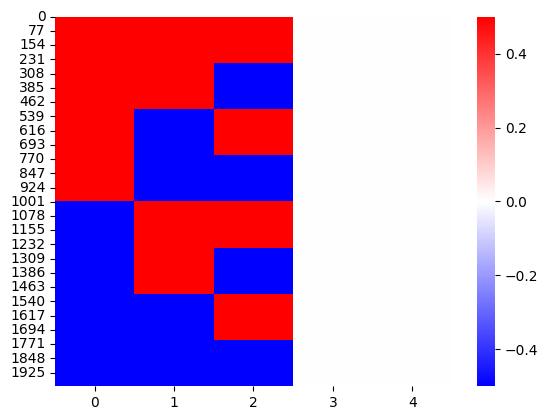

In [5]:
sns.heatmap(X, cmap="bwr")

<Axes: >

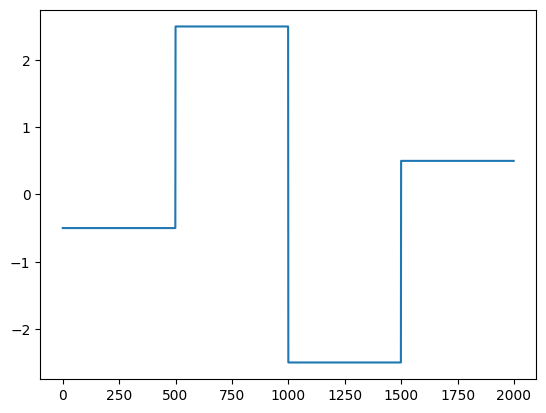

In [6]:
sns.lineplot(y)

In [7]:
np.cov(X.T)

array([[0.25012506, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.25012506, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.25012506, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [8]:
X.mean(axis=0)

array([0., 0., 0., 0., 0.])

### Simple XGBoost model

In [9]:
# train a model with single tree
Xd = xgboost.DMatrix(X, label=y)
model = xgboost.train({"eta": 1, "max_depth": 3, "base_score": 0, "lambda": 0}, Xd, 1)

print("Model error =", np.linalg.norm(y - model.predict(Xd)))
print(model.get_dump(with_stats=True)[0])

Model error = 0.0
0:[f1<0.5] yes=1,no=2,missing=2,gain=4500,cover=2000
	1:[f0<0.5] yes=3,no=4,missing=4,gain=1000,cover=1000
		3:leaf=0.5,cover=500
		4:leaf=2.5,cover=500
	2:[f0<0.5] yes=5,no=6,missing=6,gain=1000,cover=1000
		5:leaf=-2.5,cover=500
		6:leaf=-0.5,cover=500



In [11]:
pred = model.predict(Xd, output_margin=True)

explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)

shap_values = explanation.values
# make sure the SHAP values add up to marginal predictions
np.abs(shap_values.sum(axis=1) + explanation.base_values - pred).max()

np.float32(0.0)

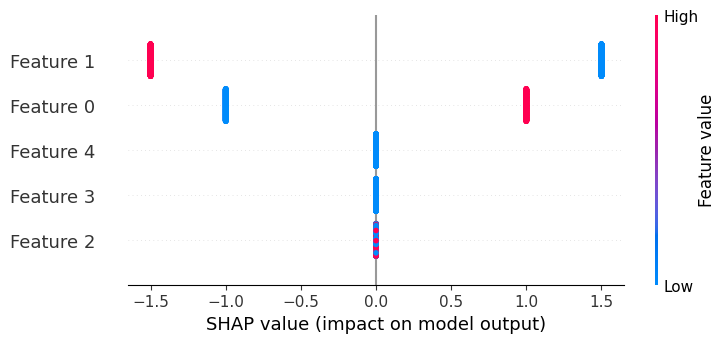

In [12]:
shap.plots.beeswarm(explanation)

### Linear regression

In [13]:
lr = LinearRegression()
lr.fit(X, y)
lr_pred = lr.predict(X)
lr.coef_.round(2)

array([ 2., -3., -0.,  0.,  0.])

In [14]:
shap_values

array([[ 1. , -1.5,  0. ,  0. ,  0. ],
       [ 1. , -1.5,  0. ,  0. ,  0. ],
       [ 1. , -1.5,  0. ,  0. ,  0. ],
       ...,
       [-1. ,  1.5,  0. ,  0. ,  0. ],
       [-1. ,  1.5,  0. ,  0. ,  0. ],
       [-1. ,  1.5,  0. ,  0. ,  0. ]], shape=(2000, 5), dtype=float32)

In [15]:
lr.coef_ * (X - X.mean(0))

array([[ 1.00000000e+00, -1.50000000e+00, -5.27441486e-16,
         0.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00, -1.50000000e+00, -5.27441486e-16,
         0.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00, -1.50000000e+00, -5.27441486e-16,
         0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.00000000e+00,  1.50000000e+00,  5.27441486e-16,
         0.00000000e+00,  0.00000000e+00],
       [-1.00000000e+00,  1.50000000e+00,  5.27441486e-16,
         0.00000000e+00,  0.00000000e+00],
       [-1.00000000e+00,  1.50000000e+00,  5.27441486e-16,
         0.00000000e+00,  0.00000000e+00]], shape=(2000, 5))

In [16]:
main_effect_shap_values = lr.coef_ * (X - X.mean(0))
np.linalg.norm(shap_values - main_effect_shap_values)

np.float64(1.293369150704416e-13)

In [17]:
shap_interaction_values = explainer.shap_interaction_values(Xd)
shap_interaction_values[0]

array([[ 1. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. , -1.5,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ]], dtype=float32)

In [18]:
np.abs(shap_interaction_values.sum((1, 2)) + explainer.expected_value - pred).max()

np.float32(0.0)

In [21]:
main_effect_shap_values[0]

array([ 1.00000000e+00, -1.50000000e+00, -5.27441486e-16,  0.00000000e+00,
        0.00000000e+00])

In [19]:
total = 0
for i in range(N):
    for j in range(5):
        total += np.abs(shap_interaction_values[i, j, j] - main_effect_shap_values[i, j])
total

np.float64(9.048488749870245e-12)

### Explain linear model with single interaction

In [22]:
N = 2_000
X = np.zeros((N, 5))
X[:1_000, 0] = 1

X[:500, 1] = 1
X[1_000:1_500, 1] = 1

X[:250, 2] = 1
X[500:750, 2] = 1
X[1_000:1_250, 2] = 1
X[1_500:1_750, 2] = 1

X[:125, 3] = 1
X[250:375, 3] = 1
X[500:625, 3] = 1
X[750:875, 3] = 1
X[1_000:1_125, 3] = 1
X[1_250:1_375, 3] = 1
X[1_500:1_625, 3] = 1
X[1_750:1_875, 3] = 1

# we can't exactly mean center the data or XGBoost has trouble finding the splits
X[:, :4] -= 0.4999

# interaction of features is implemented as the multiplication of the features. Note that any other function of the
#  features would also work, but is harder to interpret (e.g. sin(x1*x2)).
y = 2 * X[:, 0] - 3 * X[:, 1] + 2 * X[:, 1] * X[:, 2]

<Axes: >

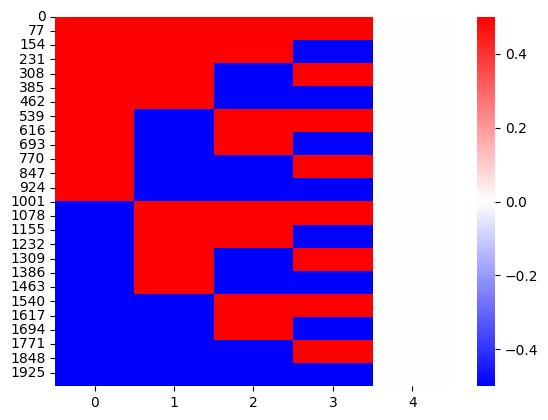

In [26]:
sns.heatmap(X, cmap="bwr")

<Axes: >

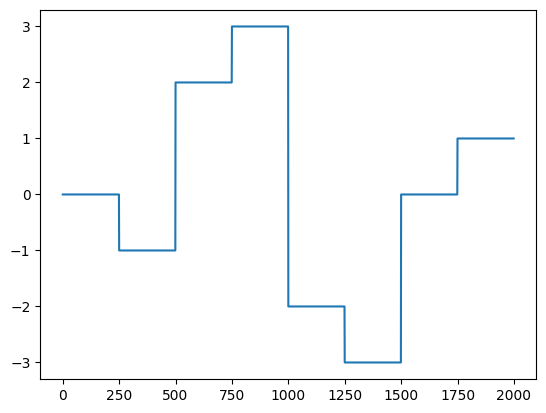

In [28]:
sns.lineplot(y)

In [23]:
X.mean(axis=0)

array([1.e-04, 1.e-04, 1.e-04, 1.e-04, 0.e+00])

In [29]:
# train a model with single tree
Xd = xgboost.DMatrix(X, label=y)
model = xgboost.train({"eta": 1, "max_depth": 4, "base_score": 0, "lambda": 0}, Xd, 1)
print("Model error =", np.linalg.norm(y - model.predict(Xd)))
print(model.get_dump(with_stats=True)[0])

Model error = 1.7365037830677604e-06
0:[f1<0.500100017] yes=1,no=2,missing=2,gain=4499.3999,cover=2000
	1:[f0<0.500100017] yes=3,no=4,missing=4,gain=1000.00024,cover=1000
		3:[f2<0.500100017] yes=7,no=8,missing=8,gain=124.950005,cover=500
			7:leaf=0.99970001,cover=250
			8:leaf=-9.99800031e-05,cover=250
		4:[f2<0.500100017] yes=9,no=10,missing=10,gain=124.950195,cover=500
			9:leaf=2.99970007,cover=250
			10:leaf=1.99989998,cover=250
	2:[f0<0.500100017] yes=5,no=6,missing=6,gain=999.999756,cover=1000
		5:[f2<0.500100017] yes=11,no=12,missing=12,gain=125.050049,cover=500
			11:leaf=-3.0000999,cover=250
			12:leaf=-1.99989998,cover=250
		6:[f2<0.500100017] yes=13,no=14,missing=14,gain=125.050018,cover=500
			13:leaf=-1.00010002,cover=250
			14:leaf=0.000100019999,cover=250



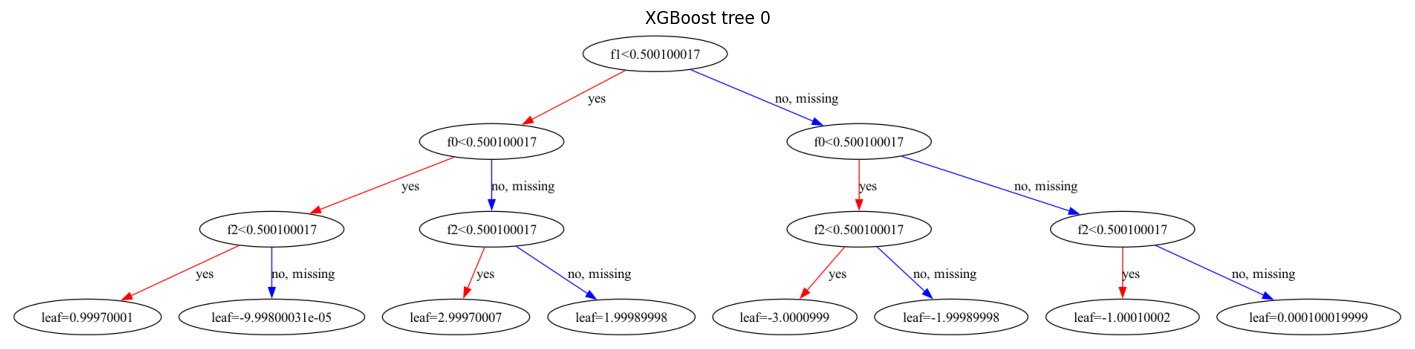

In [37]:
# plot the first tree in the trained booster
fig, ax = plt.subplots(figsize=(18, 6))
xgboost.plot_tree(model, num_trees=0, ax=ax)
ax.set_title("XGBoost tree 0")
plt.show()


In [38]:
pred = model.predict(Xd, output_margin=True)

explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)

shap_values = explanation.values
# make sure the SHAP values add up to marginal predictions
np.abs(shap_values.sum(axis=1) + explanation.base_values - pred).max()

np.float32(4.7683716e-07)

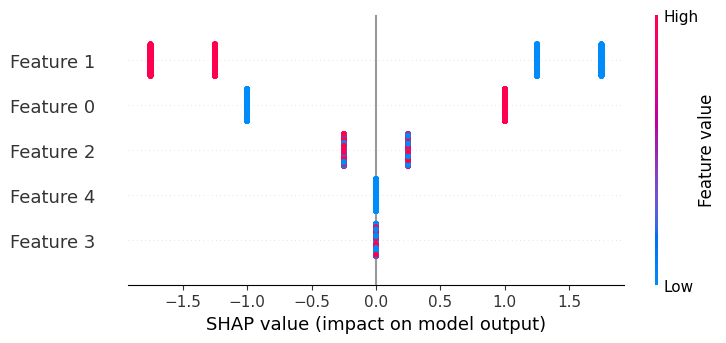

In [40]:
shap.plots.beeswarm(explanation)

In [41]:
lr = LinearRegression()
lr.fit(X, y)
lr_pred = lr.predict(X)
lr.coef_.round(2)

array([ 2., -3.,  0.,  0.,  0.])

In [42]:
main_effect_shap_values = lr.coef_ * (X - X.mean(0))
np.linalg.norm(shap_values - main_effect_shap_values)

np.float64(15.811387829626845)

In [43]:
shap_interaction_values = explainer.shap_interaction_values(Xd)
shap_interaction_values[0].round(2)

array([[ 1.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  , -1.5 ,  0.25,  0.  ,  0.  ],
       [ 0.  ,  0.25,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ]], dtype=float32)

In [44]:
np.abs(shap_interaction_values.sum((1, 2)) + explainer.expected_value - pred).max()

np.float32(4.7683716e-07)

In [45]:
total = 0
for i in range(N):
    for j in range(5):
        total += np.abs(shap_interaction_values[i, j, j] - main_effect_shap_values[i, j])
total

np.float64(0.0005347490643729786)

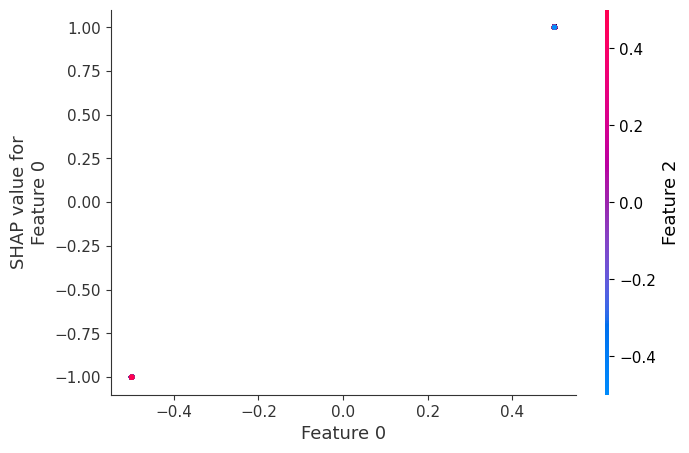

In [ ]:
shap.dependence_plot(0, shap_values, X)

/Users/kristian.ehlert/projects/kaggle/kego/competitions/general/shap-tutorials/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/kristian.ehlert/projects/kaggle/kego/competitions/general/shap-tutorials/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


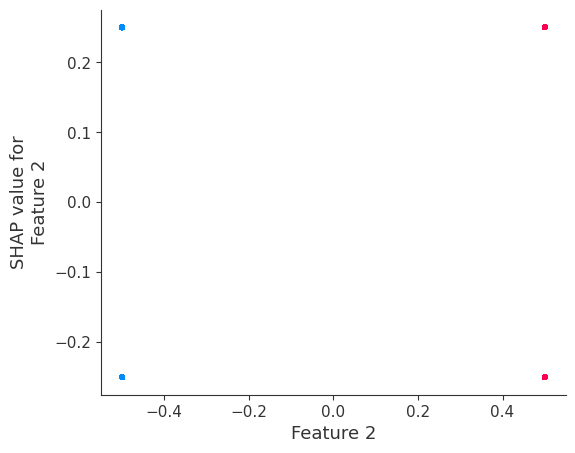

In [47]:
shap.dependence_plot(2, shap_values, X)